In [1]:
import sklearn, lightgbm, xgboost, catboost, optuna, shap
print("sklearn", sklearn.__version__)    # 1.0 이상 (StratifiedGroupKFold 필요)
print("lightgbm", lightgbm.__version__)
print("xgboost", xgboost.__version__)    # 2.0 이상 가정 (early_stopping_rounds 생성자 방식)
print("catboost", catboost.__version__)
print("optuna", optuna.__version__)
print("shap", shap.__version__)

sklearn 1.8.0
lightgbm 4.6.0
xgboost 3.2.0
catboost 1.2.10
optuna 4.8.0
shap 0.51.0


In [2]:
# ==============================================================
# 라이브러리 + 한글 폰트
# ==============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform, os, json, warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (f1_score, accuracy_score,
                             classification_report, confusion_matrix)
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna
import shap
import joblib

# ★ 순서 중요: sns.set_style이 font.family를 덮어쓰므로 반드시 폰트 설정보다 먼저!
sns.set_style("whitegrid")
def set_korean_font():
    s = platform.system()
    if s == "Darwin":      plt.rcParams["font.family"] = "AppleGothic"
    elif s == "Windows":   plt.rcParams["font.family"] = "Malgun Gothic"
    else:                  plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False
set_korean_font()

optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 100)
os.makedirs("../../figures", exist_ok=True)
os.makedirs("../../models", exist_ok=True)
os.makedirs("../../data/processed/4_model", exist_ok=True)
SEED = 42

In [3]:
# ==============================================================
# step11 로드 + 분할(split_assignment) 병합
# ==============================================================
df = pd.read_csv("../../data/processed/3_eda/step11_features.csv",
                 encoding="utf-8-sig", low_memory=False)
print(f"데이터: {df.shape}")   # (2408699, 92)

SPLIT_PATH = "../../data/processed/4_model/split_assignment.csv"

if os.path.exists(SPLIT_PATH):
    split = pd.read_csv(SPLIT_PATH, encoding="utf-8-sig")
    print("기존 분할 로드 (회귀팀과 공유) — 새로 만들지 말 것!")
else:
    # 최초 1회만 실행됨 — 농장 단위 + 등급 비율 유지 분할
    from sklearn.model_selection import StratifiedGroupKFold
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    dev_idx, hold_idx = next(sgkf.split(df, df["LAST_GRADE"],
                                        groups=df["FARM_UNIQUE_NO"]))
    df["split"] = "dev"; df.loc[hold_idx, "split"] = "holdout"
    df["fold"] = -1
    dev_tmp = df[df["split"] == "dev"]
    sgkf2 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    for k, (_, va) in enumerate(sgkf2.split(dev_tmp, dev_tmp["LAST_GRADE"],
                                            groups=dev_tmp["FARM_UNIQUE_NO"])):
        df.loc[dev_tmp.index[va], "fold"] = k
    df[["CATTLE_NO","split","fold"]].to_csv(SPLIT_PATH, index=False,
                                            encoding="utf-8-sig")
    split = df[["CATTLE_NO","split","fold"]]
    print("분할 새로 생성 후 저장")

df = df.merge(split, on="CATTLE_NO", how="left") if "split" not in df.columns else df
print(df["split"].value_counts())
print("dev fold 분포:\n", df[df['split']=='dev']['fold'].value_counts().sort_index())

# 분할 자체 검증 — 농장이 두 영역에 걸치면 누수
farm_check = df.groupby("FARM_UNIQUE_NO")["split"].nunique()
assert (farm_check > 1).sum() == 0, "농장 누수 발견! 분할 파일 확인 필요"
print("농장 누수 검증 통과")

데이터: (2408699, 92)
기존 분할 로드 (회귀팀과 공유) — 새로 만들지 말 것!
split
dev        1926959
holdout     481740
Name: count, dtype: int64
dev fold 분포:
 fold
0    385392
1    385392
2    385392
3    385391
4    385392
Name: count, dtype: int64
농장 누수 검증 통과


In [4]:
# ==============================================================
# 트랙1 피처 — "test에서 계산 가능한가"로 선별
# ==============================================================
EXCLUDE = {
    # ① 타깃 자체·타깃 파생
    "LAST_GRADE", "grade_num",
    # ② test에 없는 도축 후 측정값 (정답 누수 — 절대 금지)
    "BACKFAT","REA","WINDEX","INSFAT","YUKSAK","FATSAK","TISSUE","GROWTH",
    "WGRADE","COST_AMT",
    # ③ ID·해시 (그 자체로는 의미 없음 — 빈도 인코딩본을 대신 사용)
    "CATTLE_NO","FARM_UNIQUE_NO","stn",
    "KPN_NO","FATHER_CATTLE_NO","MOTHER_ANIMAL_NO",
    "F_GMOTHER_ANIMAL_NO","F_GFATHER_CATTLE_NO",
    "M_GMOTHER_ANIMAL_NO","M_GFATHER_CATTLE_NO",
    # ④ 날짜 원본 (연/월/분기/계절 파생으로 대체)
    "ABATT_DATE","JUDGE_DATE","BIRTH_YMD",
    # ⑤ 문자 범주 원본 (원-핫 더미로 대체)
    "sido","sigungu","eupmyeondong","JUDGE_SEX",
    "abatt_season","birth_season","farm_size","고온_bin",
    # ⑥ 상수 (THI 폐사 등급은 데이터 기간에 0일)
    "days_폐사",
    # ⑦ 분할 정보
    "split","fold",
}
features_track1 = [c for c in df.columns
                   if c not in EXCLUDE and pd.api.types.is_numeric_dtype(df[c])]
print(f"트랙1 피처: {len(features_track1)}개")   # 58개

# 참고-사후 비교용 (육질 포함 — 제출 불가, 보고서 비교 전용)
QUALITY = ["BACKFAT","REA","WINDEX","INSFAT","YUKSAK","FATSAK","TISSUE","GROWTH"]
features_post = features_track1 + QUALITY
print(f"참고-사후 피처: {len(features_post)}개")  # 66개

트랙1 피처: 58개
참고-사후 피처: 66개


In [5]:
# ==============================================================
# 등급 → 정수 (16개, 품질 순서대로)
# ==============================================================
GRADE_ORDER = ["등외","3C","3B","3A","2C","2B","2A","1C","1B","1A",
               "1+C","1+B","1+A","1++C","1++B","1++A"]   # 나쁨 → 좋음
grade_to_idx = {g: i for i, g in enumerate(GRADE_ORDER)}
idx_to_grade = {i: g for g, i in grade_to_idx.items()}

df["y"] = df["LAST_GRADE"].map(grade_to_idx)
assert df["y"].isnull().sum() == 0, "매핑 안 된 등급 존재!"
n_classes = 16
print(df["LAST_GRADE"].value_counts().reindex(GRADE_ORDER).to_string())

LAST_GRADE
등외        5540
3C       23542
3B       97576
3A       47214
2C       62938
2B      195866
2A      127410
1C      116976
1B      299290
1A      168174
1+C     130094
1+B     311222
1+A     167246
1++C    128997
1++B    319588
1++A    207026


In [6]:
# ==============================================================
# dev/holdout 분리 + 결측 처리 유틸
# ==============================================================
dev  = df[df["split"] == "dev"].reset_index(drop=True)
hold = df[df["split"] == "holdout"].reset_index(drop=True)
print(f"개발: {len(dev):,} / 홀드아웃: {len(hold):,}")

def prepare_X(train_X, *other_Xs):
    """train 중앙값으로 결측 대치 (누수 방지: 중앙값은 train에서만 계산).
    ① inf→NaN ② train 중앙값 대치 ③ 그래도 NaN인(전부결측) 컬럼은 제거."""
    train_X = train_X.replace([np.inf, -np.inf], np.nan)
    med = train_X.median(numeric_only=True)
    out = [train_X.fillna(med)]
    for X_ in other_Xs:
        out.append(X_.replace([np.inf, -np.inf], np.nan).fillna(med))
    # 전부 결측이라 중앙값조차 없는 컬럼 방어 (실데이터 스모크에서 실제 발생)
    bad = out[0].columns[out[0].isnull().any()].tolist()
    if bad:
        print(f"  [방어] 전부 결측 컬럼 제거: {bad}")
        out = [o.drop(columns=bad) for o in out]
    return out if len(out) > 1 else out[0]

# fold 인덱스 리스트 (위치 기반)
fold_indices = [(np.where(dev["fold"] != k)[0], np.where(dev["fold"] == k)[0])
                for k in range(5)]
y_dev = dev["y"]

# ★ heat_high 임계값을 dev 분위 하나로 통일 (train·test 동일 기준선)
#   step11의 heat_high는 전체(2.4M) 분위로 만들어졌음 → dev 분위로 다시 계산해 일관성 확보
HEAT_Q75 = float(np.nanquantile(dev["ratio_고온"], 0.75))   # ← test에서도 이 값을 재사용
for part in (dev, hold):
    part["heat_high"] = (part["ratio_고온"] >= HEAT_Q75).astype(int)
X_t1 = dev[features_track1]                                  # heat_high 갱신 반영
print(f"heat_high 임계값(dev 75분위) = {HEAT_Q75:.4f}")

개발: 1,926,959 / 홀드아웃: 481,740
heat_high 임계값(dev 75분위) = 0.4486


In [7]:
# ==============================================================
# 공통 5-fold CV 러너 — 4개 모델을 같은 조건에서
# ==============================================================
def run_cv(name, make_model, X_all, y_all, fold_indices,
           n_folds=5, needs_scaling=False, use_sample_weight=False,
           fit_kwargs_fn=None):
    """make_model(): 새 모델 객체 반환. fit_kwargs_fn(X_va,y_va): fit 추가 인자."""
    results, oof = [], np.full(len(X_all), -1, dtype=int)
    last_model = None
    for fold_i, (tr_idx, va_idx) in enumerate(fold_indices[:n_folds]):
        X_tr, X_va = X_all.iloc[tr_idx], X_all.iloc[va_idx]
        y_tr, y_va = y_all.iloc[tr_idx], y_all.iloc[va_idx]
        X_tr, X_va = prepare_X(X_tr, X_va)

        if needs_scaling:
            sc = StandardScaler()
            X_tr = pd.DataFrame(sc.fit_transform(X_tr), columns=X_tr.columns)
            X_va = pd.DataFrame(sc.transform(X_va),  columns=X_va.columns)

        model = make_model()
        kwargs = fit_kwargs_fn(X_va, y_va) if fit_kwargs_fn else {}
        if use_sample_weight:   # XGBoost용 — 클래스 균형 가중치
            kwargs["sample_weight"] = compute_sample_weight("balanced", y_tr)
        model.fit(X_tr, y_tr, **kwargs)

        pred = np.asarray(model.predict(X_va)).ravel().astype(int)  # ★CatBoost (n,1) 대응
        oof[va_idx] = pred
        f1m = f1_score(y_va, pred, average="macro")
        acc = accuracy_score(y_va, pred)
        results.append({"fold": fold_i, "macro_f1": round(f1m,4), "acc": round(acc,4)})
        print(f"  [{name}] fold {fold_i}: Macro-F1={f1m:.4f}, Acc={acc:.4f}")
        last_model = model
    r = pd.DataFrame(results)
    print(f"  [{name}] 평균 Macro-F1 = {r['macro_f1'].mean():.4f} ± {r['macro_f1'].std():.4f}")
    return r, oof, last_model

In [8]:
# ==============================================================
# 로지스틱 회귀 — 속도 때문에 층화 서브샘플로 학습 (베이스라인 용도)
# ==============================================================
# 192만 행 × 58변수 × 16클래스 전체 학습은 매우 오래 걸림.
# 베이스라인은 "비교 기준점"이므로 30만 행 층화 샘플이면 충분.
LOGREG_N = 300_000     # TODO: 시간 여유 있으면 늘려볼 것

# X_t1 = dev[features_track1] 는 셀 6에서 이미 정의됨 (heat_high 갱신 반영)
# ★ 층화 샘플: groupby.sample(frac=)이 pandas 2.x 권장 (옛 apply+sample은 deprecation 경고)
frac = min(1.0, LOGREG_N / len(dev))
sub = dev.groupby("y", group_keys=False).sample(frac=frac, random_state=SEED).reset_index(drop=True)
sub_folds = [(np.where(sub["fold"] != k)[0], np.where(sub["fold"] == k)[0])
             for k in range(5)]
print(f"로지스틱용 샘플: {len(sub):,}행 (등급 비율 유지)")

logreg_df, logreg_oof, _ = run_cv(
    "Logistic",
    lambda: LogisticRegression(max_iter=2000, class_weight="balanced",
                               random_state=SEED),
    sub[features_track1], sub["y"], sub_folds,
    needs_scaling=True)

로지스틱용 샘플: 299,999행 (등급 비율 유지)
  [Logistic] fold 0: Macro-F1=0.1640, Acc=0.1499
  [Logistic] fold 1: Macro-F1=0.1673, Acc=0.1541
  [Logistic] fold 2: Macro-F1=0.1605, Acc=0.1475
  [Logistic] fold 3: Macro-F1=0.1630, Acc=0.1513
  [Logistic] fold 4: Macro-F1=0.1607, Acc=0.1520
  [Logistic] 평균 Macro-F1 = 0.1631 ± 0.0028


In [10]:
# ==============================================================
# LightGBM — 메인 모델, 5-fold 전체
# ==============================================================
LGB_BASE = dict(objective="multiclass", num_class=n_classes,
                learning_rate=0.05, n_estimators=500,
                max_depth=8, num_leaves=63, min_child_samples=50,
                class_weight="balanced", verbose=-1,
                n_jobs=-1, random_state=SEED)

lgb_df, lgb_oof, lgb_last = run_cv(
    "LightGBM",
    lambda: lgb.LGBMClassifier(**LGB_BASE),
    X_t1, y_dev, fold_indices,
    fit_kwargs_fn=lambda X_va, y_va: dict(
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(50, verbose=False)]))

  [LightGBM] fold 0: Macro-F1=0.2045, Acc=0.1735
  [LightGBM] fold 1: Macro-F1=0.2055, Acc=0.1735
  [LightGBM] fold 2: Macro-F1=0.2013, Acc=0.1704
  [LightGBM] fold 3: Macro-F1=0.2044, Acc=0.1725
  [LightGBM] fold 4: Macro-F1=0.2013, Acc=0.1721
  [LightGBM] 평균 Macro-F1 = 0.2034 ± 0.0020


In [12]:
# ==============================================================
# Optuna — LightGBM 튜닝 (빠르고 + 크래시 안전)
#   ① 탐색은 층화 서브샘플(20만)로  → 학습 ~8배 빠름 (파라미터 순위는 보존)
#   ② SQLite에 진행 저장 → 죽어도 이어서 재개 (8시간 날리는 일 없음)
#   ③ learning_rate 고정 + early stopping이 n_estimators 결정 → 탐색공간 축소
#   ④ 나쁜 trial은 logloss 보고로 조기 가지치기 → 몇 초 만에 폐기
# ==============================================================
import optuna, json, numpy as np
from sklearn.model_selection import train_test_split

N_TRIALS   = 40                                    # 죽어도 누적됨. 30~50 권장
TUNE_ROWS  = 200_000                               # 탐색용 서브샘플 (150만 → 20만)
STORAGE    = "sqlite:///optuna_lgbm_track1.db"     # ★ 진행이 여기 저장됨
STUDY_NAME = "lgbm_track1_macroF1"

tr_idx, va_idx = fold_indices[0]
X_tr_full, X_va = prepare_X(X_t1.iloc[tr_idx], X_t1.iloc[va_idx])
y_tr_full, y_va = y_dev.iloc[tr_idx].to_numpy(), y_dev.iloc[va_idx].to_numpy()

# 층화 서브샘플: 등급 비율 유지하며 train만 20만 행으로
if len(X_tr_full) > TUNE_ROWS:
    X_tr, _, y_tr, _ = train_test_split(
        X_tr_full, y_tr_full, train_size=TUNE_ROWS,
        stratify=y_tr_full, random_state=SEED)
else:
    X_tr, y_tr = X_tr_full, y_tr_full
print(f"탐색 train={len(X_tr):,}행 / valid={len(X_va):,}행")

def objective(trial):
    params = dict(
        objective="multiclass", num_class=n_classes,
        learning_rate=0.05,                              # ★ 고정
        n_estimators=2000,                               # ★ 크게 + early stopping이 결정
        max_depth=trial.suggest_int("max_depth", 4, 9),          # 12 → 9
        num_leaves=trial.suggest_int("num_leaves", 31, 127),     # 255 → 127
        min_child_samples=trial.suggest_int("min_child_samples", 50, 400),
        subsample=trial.suggest_float("subsample", 0.6, 1.0), subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        class_weight="balanced", n_jobs=-1, verbosity=-1,
        force_col_wise=True, random_state=SEED)

    def prune_cb(env):                                   # 나쁜 trial 조기 폐기
        for _, metric, value, _ in env.evaluation_result_list:
            if metric == "multi_logloss":
                trial.report(-value, step=env.iteration) # maximize와 부호 맞춤
                if trial.should_prune():
                    raise optuna.TrialPruned()

    m = lgb.LGBMClassifier(**params)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="multi_logloss",
          callbacks=[lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(0), prune_cb])
    pred = np.asarray(m.predict(X_va)).ravel()
    return f1_score(y_va, pred, average="macro")

study = optuna.create_study(
    study_name=STUDY_NAME, storage=STORAGE, load_if_exists=True,   # ★ 재개
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=100))

done = sum(t.state.name == "COMPLETE" for t in study.trials)
print(f"이미 끝난 trial: {done}개 → 목표 {N_TRIALS}개까지 추가 진행")

study.optimize(objective, n_trials=N_TRIALS,
               timeout=60*60,           # ★ 1시간 예산 상한 (넘으면 자동 종료)
               catch=(Exception,),      # ★ trial 하나 터져도 study는 계속
               show_progress_bar=True)

print(f"\n최적 Macro-F1(fold0, 서브샘플): {study.best_value:.4f}")
best_params = dict(study.best_params, learning_rate=0.05, n_estimators=2000)
print(json.dumps(best_params, indent=2, ensure_ascii=False))

탐색 train=200,000행 / valid=385,392행
이미 끝난 trial: 0개 → 목표 40개까지 추가 진행


  0%|          | 0/40 [00:00<?, ?it/s]


최적 Macro-F1(fold0, 서브샘플): 0.2018
{
  "max_depth": 8,
  "num_leaves": 101,
  "min_child_samples": 66,
  "subsample": 0.8882734549912698,
  "colsample_bytree": 0.8131540082298779,
  "reg_alpha": 0.001030408764726463,
  "reg_lambda": 0.7045490097809957,
  "learning_rate": 0.05,
  "n_estimators": 2000
}


In [13]:
# ==============================================================
# 튜닝 후 5-fold 전체 재평가 (fold 0 점수만 믿으면 안 됨)
# ==============================================================
best_params = {**LGB_BASE, **study.best_params}
tuned_df, tuned_oof, tuned_last = run_cv(
    "LGB-tuned",
    lambda: lgb.LGBMClassifier(**best_params),
    X_t1, y_dev, fold_indices,
    fit_kwargs_fn=lambda X_va, y_va: dict(
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(50, verbose=False)]))
print(f"튜닝 전 {lgb_df['macro_f1'].mean():.4f} → 후 {tuned_df['macro_f1'].mean():.4f}")

  [LGB-tuned] fold 0: Macro-F1=0.2057, Acc=0.1744
  [LGB-tuned] fold 1: Macro-F1=0.2077, Acc=0.1746
  [LGB-tuned] fold 2: Macro-F1=0.2044, Acc=0.1720
  [LGB-tuned] fold 3: Macro-F1=0.2072, Acc=0.1735
  [LGB-tuned] fold 4: Macro-F1=0.2033, Acc=0.1733
  [LGB-tuned] 평균 Macro-F1 = 0.2057 ± 0.0019
튜닝 전 0.2034 → 후 0.2057


In [17]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def set_korean_font():
    for name in ["AppleGothic", "Apple SD Gothic Neo", "Nanum Gothic"]:
        if any(f.name == name for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False   # 마이너스(−) 깨짐 방지

set_korean_font()

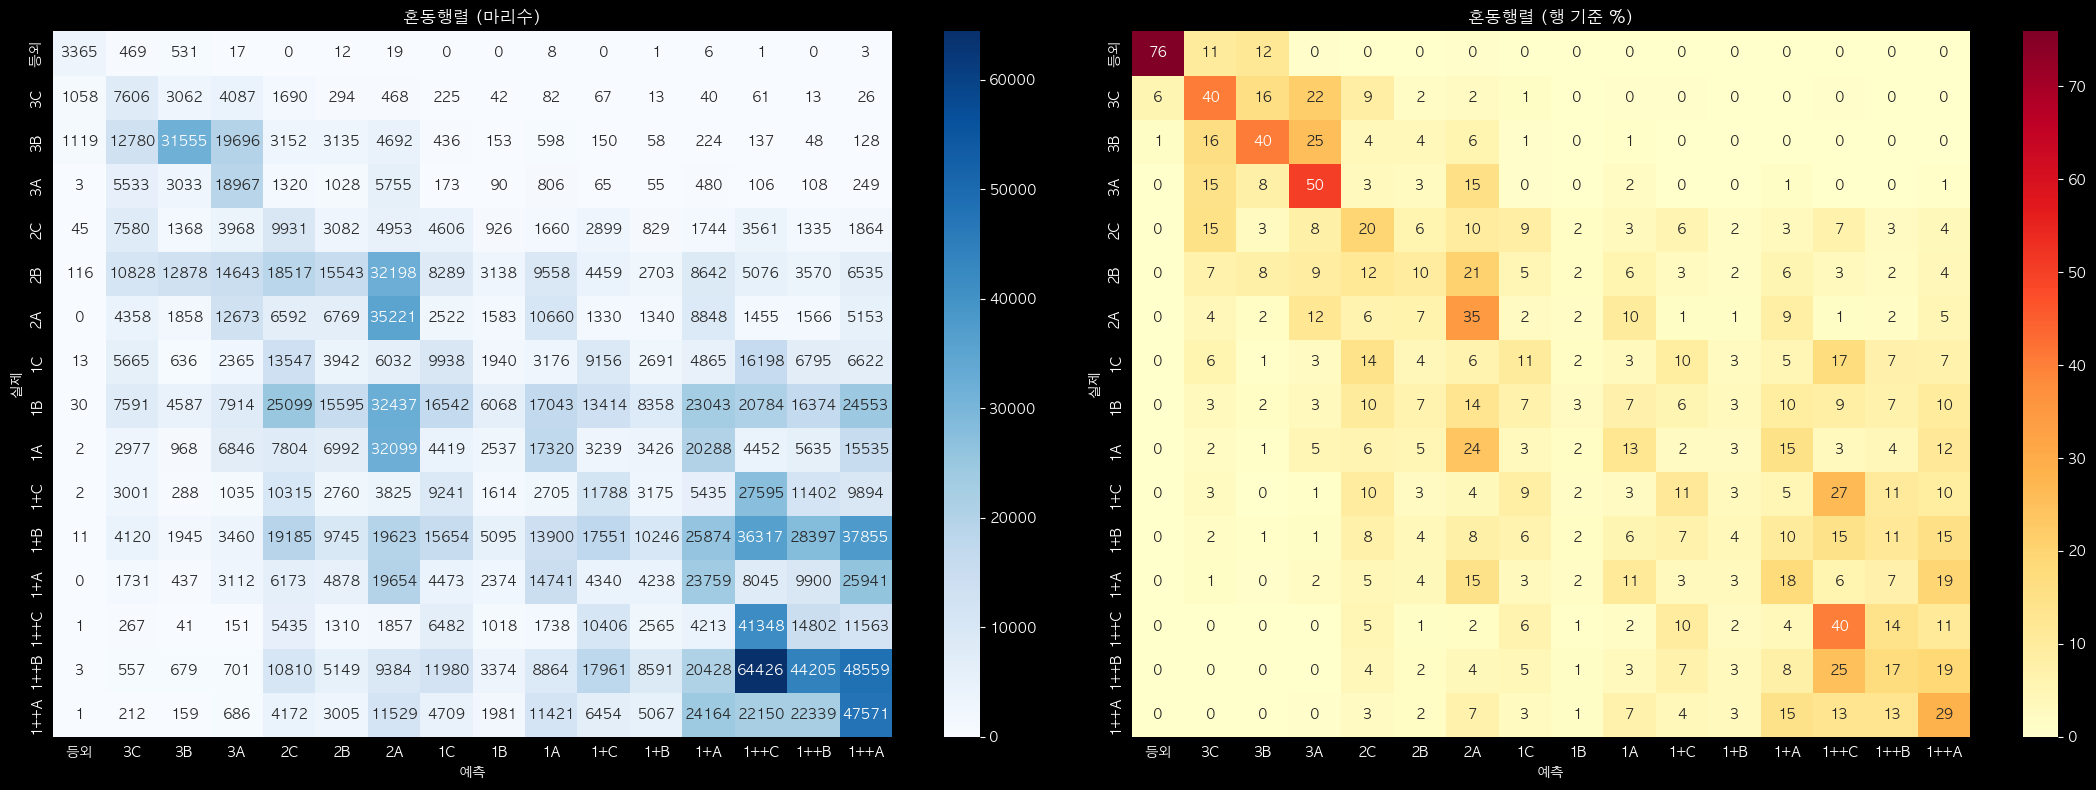

              precision    recall  f1-score   support

          등외       0.58      0.76      0.66      4432
          3C       0.10      0.40      0.16     18834
          3B       0.49      0.40      0.44     78061
          3A       0.19      0.50      0.27     37771
          2C       0.07      0.20      0.10     50351
          2B       0.19      0.10      0.13    156693
          2A       0.16      0.35      0.22    101928
          1C       0.10      0.11      0.10     93581
          1B       0.19      0.03      0.04    239432
          1A       0.15      0.13      0.14    134539
         1+C       0.11      0.11      0.11    104075
         1+B       0.19      0.04      0.07    248978
         1+A       0.14      0.18      0.16    133796
        1++C       0.16      0.40      0.23    103197
        1++B       0.27      0.17      0.21    255671
        1++A       0.20      0.29      0.23    165620

    accuracy                           0.17   1926959
   macro avg       0.21   

In [18]:
# ==============================================================
# 혼동행렬 (OOF 예측 기준 — 5개 fold 검증 예측을 합친 것)
# ==============================================================
labels = GRADE_ORDER
cm = confusion_matrix(y_dev, tuned_oof, labels=range(n_classes))
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("혼동행렬 (마리수)"); axes[0].set_xlabel("예측"); axes[0].set_ylabel("실제")
sns.heatmap(cm_norm, annot=True, fmt=".0f", cmap="YlOrRd",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("혼동행렬 (행 기준 %)"); axes[1].set_xlabel("예측"); axes[1].set_ylabel("실제")
plt.tight_layout()
plt.savefig("../../figures/19_confusion.png", dpi=100, bbox_inches="tight")
plt.show()

print(classification_report(y_dev, tuned_oof,
                            labels=range(n_classes),
                            target_names=labels, zero_division=0))

SHAP 3차원 배열: (1000, 58, 16)
                   변수  SHAP중요도
               WEIGHT 0.530701
           daily_gain 0.391644
                sex_암 0.217945
          KPN_NO_freq 0.092348
       fattening_days 0.076266
                  AGE 0.068436
FATHER_CATTLE_NO_freq 0.065240
           days_total 0.057485
           birth_year 0.044303
              days_경고 0.038060
         ws_davg_mean 0.038020
                C2023 0.035961
           death_rate 0.033427
              days_주의 0.032993
                C2025 0.032636
          rn_day_mean 0.031875
                C2024 0.031031
            sido_전라남도 0.030274
              days_양호 0.029901
             ratio_위험 0.027106


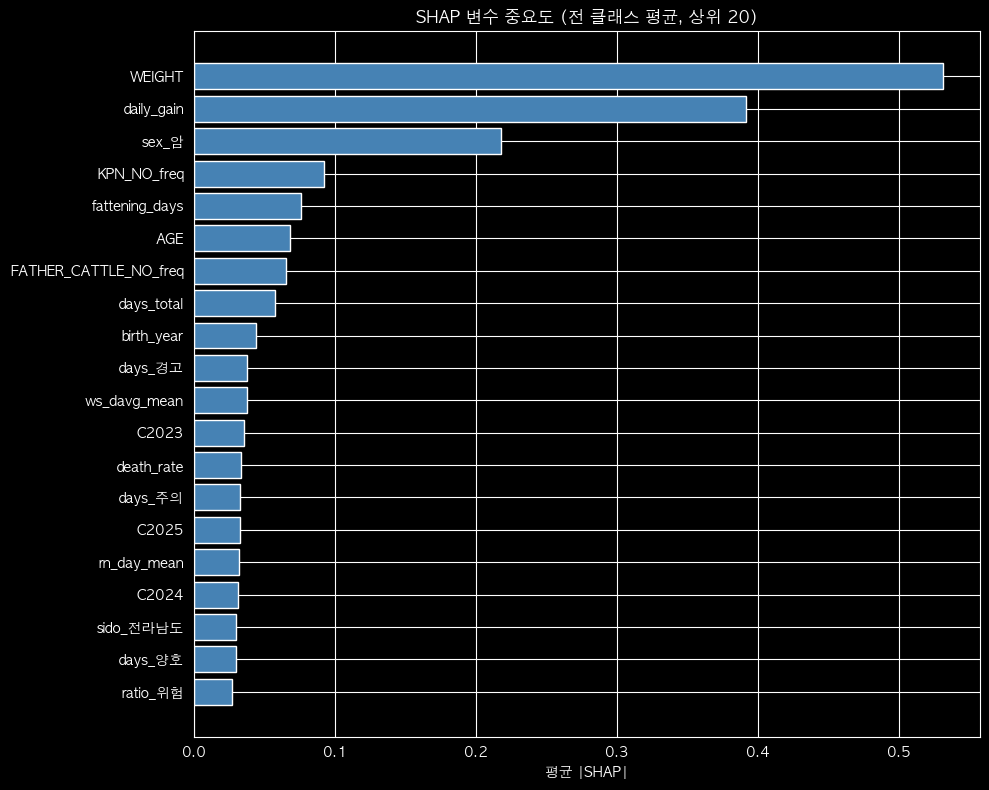

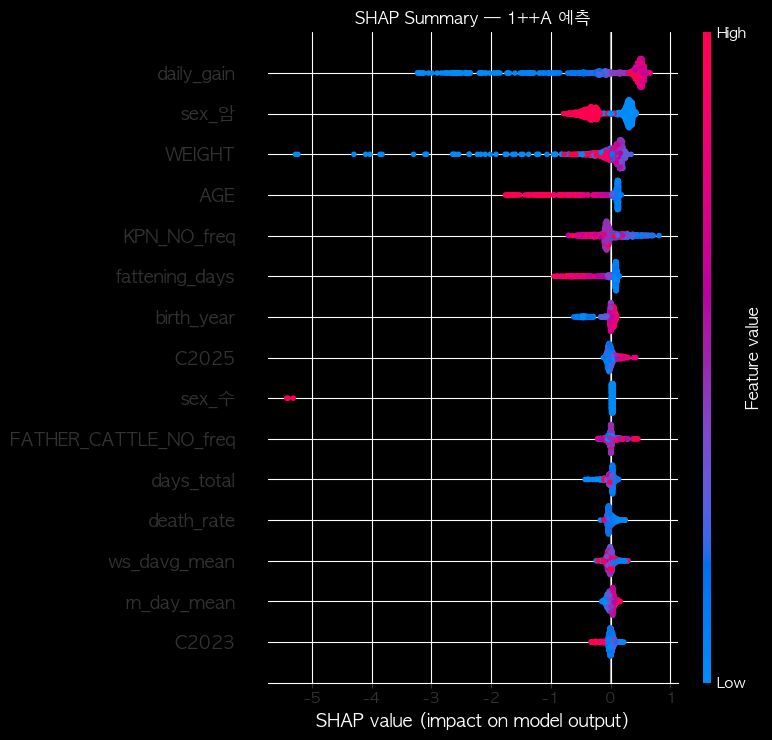

In [19]:
# ==============================================================
# SHAP — 신버전(3차원 배열)과 구버전(리스트) 모두 대응
# ==============================================================
tr_idx, va_idx = fold_indices[-1]
X_sample = prepare_X(X_t1.iloc[tr_idx], X_t1.iloc[va_idx])[1] \
    .sample(min(1000, len(va_idx)), random_state=SEED)

explainer = shap.TreeExplainer(tuned_last)
sv = explainer.shap_values(X_sample)

if isinstance(sv, list):                      # 구버전: 클래스별 리스트
    mean_abs = np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
    get_class_sv = lambda k: sv[k]
else:                                         # 신버전: (샘플, 변수, 클래스)
    print(f"SHAP 3차원 배열: {sv.shape}")
    mean_abs = np.abs(sv).mean(axis=(0, 2))
    get_class_sv = lambda k: sv[:, :, k]

imp = (pd.DataFrame({"변수": X_sample.columns, "SHAP중요도": mean_abs})
       .sort_values("SHAP중요도", ascending=False))
print(imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
top20 = imp.head(20).iloc[::-1]
plt.barh(top20["변수"], top20["SHAP중요도"], color="steelblue")
plt.xlabel("평균 |SHAP|"); plt.title("SHAP 변수 중요도 (전 클래스 평균, 상위 20)")
plt.tight_layout()
plt.savefig("../../figures/19_shap_importance.png", dpi=100, bbox_inches="tight")
plt.show()

# 최상위 등급(1++A) 기준 summary plot
k = grade_to_idx["1++A"]
shap.summary_plot(get_class_sv(k), X_sample, max_display=15, show=False)
plt.title("SHAP Summary — 1++A 예측")
plt.tight_layout()
plt.savefig("../../figures/19_shap_summary_1ppA.png", dpi=100, bbox_inches="tight")
plt.show()

imp.to_csv("../../data/processed/4_model/19_shap_importance.csv",
           index=False, encoding="utf-8-sig")

In [16]:
# ==============================================================
# 홀드아웃 — 딱 한 번만 실행. 이 점수를 보고 모델을 또 고치면 안 됨!
# ==============================================================
X_dev_full, X_hold = prepare_X(dev[features_track1], hold[features_track1])
y_hold = hold["y"]

# 홀드아웃 평가용 모델은 반드시 dev로만 학습 (holdout으로 학습하면 자기시험 = 점수 무의미)
holdout_model = lgb.LGBMClassifier(**best_params)
holdout_model.fit(X_dev_full, y_dev)
pred_hold = np.asarray(holdout_model.predict(X_hold)).ravel().astype(int)

hold_f1  = f1_score(y_hold, pred_hold, average="macro")
hold_acc = accuracy_score(y_hold, pred_hold)
print(f"홀드아웃 Macro-F1: {hold_f1:.4f} (CV 평균: {tuned_df['macro_f1'].mean():.4f})")
print(f"홀드아웃 정확도:    {hold_acc:.4f}")

홀드아웃 Macro-F1: 0.2055 (CV 평균: 0.2057)
홀드아웃 정확도:    0.1755


In [20]:
# ==============================================================
# CV·홀드아웃 결과 저장 (제출 모델은 3.5장에서 저장)
# ==============================================================
summary = {
    "logistic_cv":  round(logreg_df["macro_f1"].mean(), 4),
    "lgb_cv":       round(lgb_df["macro_f1"].mean(), 4),
    "xgb_cv":       round(xgb_df["macro_f1"].mean(), 4),
    "cat_cv":       round(cat_df["macro_f1"].mean(), 4),
    "lgb_tuned_cv": round(tuned_df["macro_f1"].mean(), 4),
    "post_ref_cv":  round(post_df["macro_f1"].mean(), 4),
    "holdout_f1":   round(hold_f1, 4),
    "holdout_acc":  round(hold_acc, 4),
    "best_params":  study.best_params,
    "n_features":   len(features_track1),
}
with open("../../data/processed/4_model/19_results.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print(json.dumps(summary, ensure_ascii=False, indent=2))

NameError: name 'xgb_df' is not defined